# BCI Giuseppe Bonomo HGD

In [1]:
#%%
#!git clone https://github.com/marco-siino/EEG-ATCNet.git
#!git clone https://github.com/Bonomo31/Tesi.git
%pip install mne
%pip install PyWavelets
#Le ulitme versioni non sono compatibili con le librerie usate
#in preprocess_HGD.py, quindi si è optato a utilizzare una versione meno recente
%pip install braindecode==0.3

import os
import sys
import shutil
import time
import pywt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import scipy.signal as signal
import requests
from pathlib import Path
from tqdm import tqdm


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
#os.chdir("/content/Tesi/HGD/")
#os.chdir("/Users/giuseppebonomo/Desktop/Tesi/HGD/")
os.chdir("/home/giuseppe_bonomo/DATASET/HGD/")

import models

from preprocess import get_data
#from keras.utils.vis_utils import plot_model

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


2025-12-19 11:57:14.699047: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-19 11:57:14.710873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766141834.723825 1000539 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766141834.727315 1000539 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766141834.737831 1000539 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Organize the dataset.

In [2]:
#Creo la cartella dataset
os.makedirs("dataset", exist_ok=True)

# Definizione URL base
train_url = "https://gin.g-node.org/robintibor/high-gamma-dataset/raw/master/data/train"
test_url = "https://gin.g-node.org/robintibor/high-gamma-dataset/raw/master/data/test"

# Creazione cartelle se non esistono
train_dir = Path("dataset/train")
test_dir = Path("dataset/test")
train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

def download_file(url, filepath):
    #Scarica un file con una barra di avanzamento
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        total_size = int(response.headers.get("content-length", 0))
        with open(filepath, "wb") as f, tqdm(
            desc=filepath.name, total=total_size, unit="B", unit_scale=True
        ) as bar:
            for chunk in response.iter_content(chunk_size=1024):
                f.write(chunk)
                bar.update(len(chunk))
    else:
        print(f"Errore nel download di {url}: {response.status_code}")

#Scarico i dati di train e test per High Gamma Dataset controllo se esistono già
if not os.path.exists("dataset/train/1.mat"):
    # Scarico i file di train e test
    for i in range(1, 15):
        train_file = train_dir / f"{i}.mat"
        test_file = test_dir / f"{i}.mat"

        download_file(f"{train_url}/{i}.mat", train_file)
        download_file(f"{test_url}/{i}.mat", test_file)

    print("Download completato!")
else:
    print("I dati sono già presenti")


I dati sono già presenti


# Functions definitions

In [3]:
#%%
def draw_learning_curves(history, sub):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy - subject: ' + str(sub))
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss - subject: ' + str(sub))
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.close()

def draw_confusion_matrix(cf_matrix, sub, results_path, classes_labels):
    # Generate confusion matrix plot
    display_labels = classes_labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix,
                                display_labels=display_labels)
    disp.plot()
    disp.ax_.set_xticklabels(display_labels, rotation=12)
    plt.title('Confusion Matrix of Subject: ' + sub )
    plt.savefig(results_path + '/subject_' + sub + '.png')
    plt.show()

def draw_performance_barChart(num_sub, metric, label):
    fig, ax = plt.subplots()
    x = list(range(1, num_sub+1))
    ax.bar(x, metric, 0.5, label=label)
    ax.set_ylabel(label)
    ax.set_xlabel("Subject")
    ax.set_xticks(x)
    ax.set_title('Model '+ label + ' per subject')
    ax.set_ylim([0,1])

# Preprocessing functions definition

## DB4 (Soft -> Threshold 5.5)

In [4]:
def db4_soft(signal, wavelet='db4', level=4, threshold=5.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """


    print("Lunghezza originale:", signal.shape[-1])  # Dovrebbe essere 1125
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)
    print("Lunghezza coefficiente di approssimazione:", len(coeffs[0]))

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='per')
    print("Lunghezza ricostruita:", len(reconstructed_signal))

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## DB4 (Hard -> Threshold 10.5)

In [5]:
def db4_hard(signal, wavelet='db4', level=4, threshold=10.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## RDWT

In [6]:
def rational_dilated_wavelet_transform(sig, wavelet='db4', levels=4, dilation_factors=None, threshold=5.5):
    """
    Applica la Rational Dilated Wavelet Transform (RDWT) a un segnale EEG multidimensionale.

    Args:
    - sig: array numpy di forma (eventi, 1, canali, campioni)
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - levels: numero di livelli di decomposizione (default 4)
    - dilation_factors: lista di fattori di dilatazione razionale (default: [3/2, 5/3, 7/4, ...])
    - threshold: soglia per i coefficienti di dettaglio (default 5.5)

    Returns:
    - Segnale ricostruito con la RDWT (stessa dimensione dell'input)
    """
    eventi, _, canali, campioni = sig.shape
    print("Lunghezza originale del segnale:", sig.shape)

    if dilation_factors is None:
        dilation_factors = [3/2, 5/3, 7/4, 9/5]

    coeffs_approx = sig.copy()  # Inizializza con il segnale originale
    detail_coeffs = []

    for i in range(levels):
        factor = dilation_factors[i]
        wavelet_filter = pywt.Wavelet(wavelet)
        lo_d, hi_d = wavelet_filter.dec_lo, wavelet_filter.dec_hi

        # Ridimensionamento dei filtri
        lo_d = signal.resample(lo_d, int(len(lo_d) * factor))
        hi_d = signal.resample(hi_d, int(len(hi_d) * factor))

        print(f"Livello {i+1}: coeffs_approx shape {coeffs_approx.shape}, lo_d shape {lo_d.shape}, hi_d shape {hi_d.shape}")

        approx = np.zeros_like(coeffs_approx)
        detail = np.zeros_like(coeffs_approx)

        # Applica la convoluzione per ogni canale EEG
        for e in range(eventi):
            for c in range(canali):
                approx[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], lo_d, mode='same')
                detail[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], hi_d, mode='same')

                # Soglia sui coefficienti di dettaglio
                detail[e, 0, c, np.abs(detail[e, 0, c, :]) < threshold] = 0

        detail_coeffs.append(detail)
        coeffs_approx = approx  # Passa l'approssimazione al livello successivo

    # Ricostruzione del segnale
    reconstructed = coeffs_approx.copy()
    for i in range(levels-1, -1, -1):
        reconstructed += detail_coeffs[i]

    print("Lunghezza del segnale ricostruito:", reconstructed.shape)
    return reconstructed

# RDWT normalized with min-max

In [7]:
def normalize_min_max(sig, reconstructed):
    """
    Normalizza il segnale ricostruito usando la normalizzazione Min-Max,
    riportandolo alla scala del segnale di input.

    Args:
    - sig: array numpy di forma (eventi, 1, canali, campioni), segnale di input
    - reconstructed: array numpy di forma (eventi, 1, canali, campioni), segnale ricostruito

    Returns:
    - Segnale ricostruito normalizzato sulla scala dell'input
    """
    min_input = np.min(sig, axis=-1, keepdims=True)
    max_input = np.max(sig, axis=-1, keepdims=True)

    min_reconstructed = np.min(reconstructed, axis=-1, keepdims=True)
    max_reconstructed = np.max(reconstructed, axis=-1, keepdims=True)

    # Evita la divisione per zero
    range_reconstructed = max_reconstructed - min_reconstructed
    range_reconstructed[range_reconstructed == 0] = 1

    normalized = (reconstructed - min_reconstructed) / range_reconstructed

    # Riporta alla scala originale
    scaled = normalized * (max_input - min_input) + min_input

    return scaled

## STFT

In [8]:
from scipy.signal import stft, istft

def apply_stft(data, fs=256, nperseg=64, noverlap=32, nfft=128, threshold=0.1):
    """
    Applies STFT-based processing similar to wavelet transforms
    Input/output shape: (events, 1, channels, samples)
    """
    events, _, channels, samples = data.shape
    processed_data = np.zeros_like(data)

    for e in range(events):
        for ch in range(channels):
            # Estrai singolo canale
            x = data[e, 0, ch, :]
            
            # Applica STFT
            f, t, Zxx = stft(x, fs=fs, nperseg=nperseg, 
                            noverlap=noverlap, nfft=nfft)
            
            # Processamento simile alla wavelet
            mag = np.abs(Zxx)
            phase = np.angle(Zxx)
            
            # Soglia sui coefficienti
            mag_thresholded = np.where(mag < threshold, 0, mag)
            
            # Ricostruzione del segnale
            _, x_rec = istft(mag_thresholded * np.exp(1j*phase), 
                           fs=fs, nperseg=nperseg, 
                           noverlap=noverlap, nfft=nfft)
            
            # Allinea lunghezza
            x_rec = x_rec[:samples]
            processed_data[e, 0, ch, :] = x_rec

    return processed_data

# Apply Preprocessing

In [9]:
def apply_preprocessing (signals_data, preprocessing):
  if preprocessing=="none":
    return signals_data
  elif preprocessing=="db4_soft":
    return db4_soft(signals_data)
  elif preprocessing=="db4_hard":
    return db4_hard(signals_data)
  elif preprocessing=="rdwt":
    return rational_dilated_wavelet_transform(signals_data)
  elif preprocessing=="rdwt_normalized":
    reconstructed = rational_dilated_wavelet_transform(signals_data)
    return normalize_min_max(signals_data, reconstructed)
  elif preprocessing=="stft":
    return apply_stft(signals_data)


# Model training function

In [10]:
#%% Training
def train(dataset_conf, train_conf, results_path):

    # remove the 'result' folder before training
    if os.path.exists(results_path):
        # Remove the folder and its contents
        shutil.rmtree(results_path)
        os.makedirs(results_path)

    # Get the current 'IN' time to calculate the overall training time
    in_exp = time.time()
    # Create a file to store the path of the best model among several runs
    best_models = open(results_path + "/best models RatioWaveNet.txt", "w")
    # Create a file to store performance during training
    log_write = open(results_path + "/log RatioWaveNet.txt", "w")

    # Get dataset parameters
    dataset = dataset_conf.get('name')
    n_sub = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard = dataset_conf.get('isStandard')
    LOSO = dataset_conf.get('LOSO')
    # Get training hyperparamters
    batch_size = train_conf.get('batch_size')
    epochs = train_conf.get('epochs')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    patience = train_conf.get('patience')
    lr = train_conf.get('lr')
    LearnCurves = train_conf.get('LearnCurves') # Plot Learning Curves?
    n_train = train_conf.get('n_train')
    model_name = train_conf.get('model')
    from_logits = train_conf.get('from_logits')

    # Initialize variables
    acc = np.zeros((n_sub, n_train))
    kappa = np.zeros((n_sub, n_train))

    # Iteration over subjects
    # for sub in range(n_sub-1, n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
    for sub in range(n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.

        print('\nTraining on subject ', sub+1)
        log_write.write( '\nTraining on subject '+ str(sub+1) +'\n')
        # Initiating variables to save the best subject accuracy among multiple runs.
        BestSubjAcc = 0
        bestTrainingHistory = []

        # Get training and validation data
        X_train, _, y_train_onehot, _, _, _ = get_data(
            data_path, sub, dataset, LOSO = LOSO, isStandard = isStandard)

        # Divide the training data into training and validation
        X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(X_train, y_train_onehot, test_size=0.2, random_state=42)


        print("\n\nBefore preprocessing X_train shape is:"+str(X_train.shape))
        print("Before preprocessing X_val shape is:"+str(X_val.shape))
        
        X_train = apply_preprocessing(X_train, preprocessing=signal_preprocessing)
        X_val = apply_preprocessing(X_val, preprocessing=signal_preprocessing)
        
        print("\n\nAfter preprocessing X_train shape is:"+str(X_train.shape))
        print("After preprocessing X_val shape is:"+str(X_val.shape))
        

        # Iteration over multiple runs
        for train in range(n_train): # How many repetitions of training for subject i.
            # Set the random seed for TensorFlow and NumPy random number generator.
            # The purpose of setting a seed is to ensure reproducibility in random operations.
            tf.random.set_seed(train+1)
            np.random.seed(train+1)

            # Get the current 'IN' time to calculate the 'run' training time
            in_run = time.time()

            # Create folders and files to save trained models for all runs
            filepath = results_path + '/saved models/run-{}'.format(train+1)
            if not os.path.exists(filepath):
                os.makedirs(filepath)
            filepath = filepath + '/subject-{}.weights.h5'.format(sub+1)

            # Create the model
            model = getModel(model_name, dataset_conf, from_logits)
            # Compile and train the model
            model.compile(loss=CategoricalCrossentropy(from_logits=from_logits), optimizer=Adam(learning_rate=lr), metrics=['accuracy'])

            # model.summary()
            # plot_model(model, to_file='plot_model.png', show_shapes=True, show_layer_names=True)

            callbacks = [
                ModelCheckpoint(filepath, monitor='val_loss', verbose=0,
                                save_best_only=True, save_weights_only=True, mode='min'),
                ReduceLROnPlateau(monitor="val_loss", factor=0.50, patience=20, verbose=0, min_lr=0.0001),
                EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=patience)
            ]
            history = model.fit(X_train, y_train_onehot, validation_data=(X_val, y_val_onehot),
                                epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=0)

            # Evaluate the performance of the trained model based on the validation data
            # Here we load the Trained weights from the file saved in the hard
            # disk, which should be the same as the weights of the current model.
            model.load_weights(filepath)
            y_pred = model.predict(X_val)

            if from_logits:
                y_pred = tf.nn.softmax(y_pred).numpy().argmax(axis=-1)
            else:
                y_pred = y_pred.argmax(axis=-1)

            labels = y_val_onehot.argmax(axis=-1)
            acc[sub, train]  = accuracy_score(labels, y_pred)
            kappa[sub, train] = cohen_kappa_score(labels, y_pred)

            # Get the current 'OUT' time to calculate the 'run' training time
            out_run = time.time()
            # Print & write performance measures for each run
            info = 'Subject: {}   seed {}   time: {:.1f} m   '.format(sub+1, train+1, ((out_run-in_run)/60))
            info = info + 'valid_acc: {:.4f}   valid_loss: {:.3f}'.format(acc[sub, train], min(history.history['val_loss']))
            print(info)
            log_write.write(info +'\n')
            # If current training run is better than previous runs, save the history.
            if(BestSubjAcc < acc[sub, train]):
                 BestSubjAcc = acc[sub, train]
                 bestTrainingHistory = history

        # Store the path of the best model among several runs
        best_run = np.argmax(acc[sub,:])
        filepath = '/saved models/run-{}/subject-{}.h5'.format(best_run+1, sub+1)+'\n'
        best_models.write(filepath)

        # Plot Learning curves
        if (LearnCurves == True):
            print('Plot Learning Curves ....... ')
            draw_learning_curves(bestTrainingHistory, sub+1)

    # Get the current 'OUT' time to calculate the overall training time
    out_exp = time.time()

    # Print & write the validation performance using all seeds
    head1 = head2 = '         '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n---------------------------------\nValidation performance (acc %):'
    info = info + '\n---------------------------------\n' + head1 +'\n'+ head2
    for run in range(n_train):
        info = info + '\nSeed {}:  '.format(run+1)
        for sub in range(n_sub):
            info = info + '{:.2f}   '.format(acc[sub, run]*100)
        info = info + '  {:.2f}   '.format(np.average(acc[:, run])*100)
    info = info + '\n---------------------------------\nAverage acc - all seeds: '
    info = info + '{:.2f} %\n\nTrain Time  - all seeds: {:.1f}'.format(np.average(acc)*100, (out_exp-in_exp)/(60))
    info = info + ' min\n---------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Close open files
    best_models.close()
    log_write.close()


# Evaluation function

In [11]:
#%% Evaluation
def test(model, dataset_conf, results_path, allRuns = True):
    # Open the  "Log" file to write the evaluation results
    log_write = open(results_path + "/log RatioWaveNet.txt", "a")

    # Get dataset paramters
    dataset = dataset_conf.get('name')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    n_classes = dataset_conf.get('n_classes')
    n_sub = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard = dataset_conf.get('isStandard')
    LOSO = dataset_conf.get('LOSO')
    classes_labels = dataset_conf.get('cl_labels')
    #Ripetuto
    #signal_preprocessing = dataset_conf.get('signal_preprocessing')

    # Test the performance based on several runs (seeds)
    runs = os.listdir(results_path+"/saved models")
    # Initialize variables
    acc = np.zeros((n_sub, len(runs)))
    kappa = np.zeros((n_sub, len(runs)))
    cf_matrix = np.zeros([n_sub, len(runs), n_classes, n_classes])

    # Iteration over subjects
    # for sub in range(n_sub-1, n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
    inference_time = 0 #  inference_time: classification time for one trial
    for sub in range(n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
        # Load data
        _, _, _, X_test, _, y_test_onehot = get_data(data_path, sub, dataset, LOSO = LOSO, isStandard = isStandard)

        X_test = apply_preprocessing(X_test, preprocessing=signal_preprocessing)

        # Iteration over runs (seeds)
        for seed in range(len(runs)):
            # Load the model of the seed.
            model.load_weights('{}/saved models/{}/subject-{}.weights.h5'.format(results_path, runs[seed], sub+1))

            inference_time = time.time()
            # Predict MI task
            y_pred = model.predict(X_test).argmax(axis=-1)
            inference_time = (time.time() - inference_time)/X_test.shape[0]
            # Calculate accuracy and K-score
            labels = y_test_onehot.argmax(axis=-1)
            acc[sub, seed]  = accuracy_score(labels, y_pred)
            kappa[sub, seed] = cohen_kappa_score(labels, y_pred)
            # Calculate and draw confusion matrix
            cf_matrix[sub, seed, :, :] = confusion_matrix(labels, y_pred, normalize='true')
            # draw_confusion_matrix(cf_matrix[sub, seed, :, :], str(sub+1), results_path, classes_labels)

    # Print & write the average performance measures for all subjects
    head1 = head2 = '                  '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n' + head1 +'\n'+ head2
    info = '\n---------------------------------\nTest performance (acc & k-score):\n'
    info = info + '---------------------------------\n' + head1 +'\n'+ head2
    for run in range(len(runs)):
        info = info + '\nSeed {}: '.format(run+1)
        info_acc = '(acc %)   '
        info_k = '        (k-sco)   '
        for sub in range(n_sub):
            info_acc = info_acc + '{:.2f}   '.format(acc[sub, run]*100)
            info_k = info_k + '{:.3f}   '.format(kappa[sub, run])
        info_acc = info_acc + '  {:.2f}   '.format(np.average(acc[:, run])*100)
        info_k = info_k + '  {:.3f}   '.format(np.average(kappa[:, run]))
        info = info + info_acc + '\n' + info_k
    info = info + '\n----------------------------------\nAverage - all seeds (acc %): '
    info = info + '{:.2f}\n                    (k-sco): '.format(np.average(acc)*100)
    info = info + '{:.3f}\n\nInference time: {:.2f}'.format(np.average(kappa), inference_time * 1000)
    info = info + ' ms per trial\n----------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Draw a performance bar chart for all subjects
    draw_performance_barChart(n_sub, acc.mean(1), 'Accuracy')
    draw_performance_barChart(n_sub, kappa.mean(1), 'k-score')
    # Draw confusion matrix for all subjects (average)
    draw_confusion_matrix(cf_matrix.mean((0,1)), 'All', results_path, classes_labels)
    # Close opened file
    log_write.close()

# Model selection and setup

In [12]:
#%%
def getModel(model_name, dataset_conf, from_logits = False):

    n_classes = dataset_conf.get('n_classes')
    n_channels = dataset_conf.get('n_channels')
    in_samples = dataset_conf.get('in_samples')

    # Select the model
    if(model_name == 'RockNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.RockNet_(
            # Dataset parameters
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            # Sliding window (SW) parameter
            n_windows = 5,
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='elu',
            )
    elif(model_name == 'RatioWaveNet'):
        model = models.RatioWaveNet(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 3,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.4,
            tcn_depth = 3,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetB'):
        model = models.RockNetB(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetC'):
        model = models.RockNetC(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetX'):
        model = models.RockNetX(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'transformer',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 3,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='gelu',
        )
    elif(model_name == 'RockNetY'):
        model = models.RockNetY(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetZ'):
        model = models.RockNetZ(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='relu',
        )
    elif(model_name == 'ATCNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.ATCNet_(
            # Dataset parameters
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            # Sliding window (SW) parameter
            n_windows = 5,
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.3,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
            )
    elif(model_name == 'TCNet_Fusion'):
        # Train using TCNet_Fusion: https://doi.org/10.1016/j.bspc.2021.102826
        model = models.TCNet_Fusion(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGTCNet'):
        # Train using EEGTCNet: https://arxiv.org/abs/2006.00622
        model = models.EEGTCNet(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNet'):
        # Train using EEGNet: https://arxiv.org/abs/1611.08024
        model = models.EEGNet_classifier(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNeX'):
        # Train using EEGNeX: https://arxiv.org/abs/2207.12369
        model = models.EEGNeX_8_32(n_timesteps = in_samples , n_features = n_channels, n_outputs = n_classes)
    elif(model_name == 'DeepConvNet'):
        # Train using DeepConvNet: https://doi.org/10.1002/hbm.23730
        model = models.DeepConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'ShallowConvNet'):
        # Train using ShallowConvNet: https://doi.org/10.1002/hbm.23730
        model = models.ShallowConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'MBEEG_SENet'):
        # Train using MBEEG_SENet: https://www.mdpi.com/2075-4418/12/4/995
        model = models.MBEEG_SENet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)

    else:
        raise Exception("'{}' model is not supported yet!".format(model_name))

    return model

# Run the simulation

## Define the run function.

In [13]:
#%%
def run(signal_preprocessing):
    # Define dataset parameters
    # Options: 'BCI2a','HGD', 'BCI2b'
    dataset = 'HGD'

    if dataset == 'BCI2a':
        in_samples = 1125
        n_channels = 22
        n_sub = 9
        n_classes = 4
        classes_labels = ['Left hand', 'Right hand','Foot','Tongue']
        data_path = 'dataset/' #os.path.expanduser('~') + '/BCI Competition IV/BCI Competition IV-2a/BCI Competition IV 2a mat/'
    elif dataset == 'HGD':
        in_samples = 1125
        n_channels = 44 
        n_sub = 14
        n_classes = 4
        classes_labels = ['Right Hand', 'Left Hand','Rest','Feet']
        data_path = 'dataset/' #os.path.expanduser('~') + '/mne_data/MNE-schirrmeister2017-data/robintibor/high-gamma-dataset/raw/master/data/'
    elif dataset == 'BCI2b':
        in_samples = 750
        n_channels = 3
        n_sub = 9
        n_classes = 2
        classes_labels = ['Left hand', 'Right hand']
        data_path = 'dataset/' #os.path.expanduser('~') + '/BCI Competition IV/BCI Competition IV-2b/BCI Competition IV 2b.mat'
    else:
        raise Exception("'{}' dataset is not supported yet!".format(dataset))

    # Create a folder to store the results of the experiment
    results_path = os.getcwd() + "/results_RatioWaveNet_5"
    if not  os.path.exists(results_path):
      os.makedirs(results_path)   # Create a new directory if it does not exist

    # Set dataset paramters
    dataset_conf = { 'name': dataset, 'n_classes': n_classes, 'cl_labels': classes_labels,
                    'n_sub': n_sub, 'n_channels': n_channels, 'in_samples': in_samples,
                    'data_path': data_path, 'isStandard': True, 'LOSO': False,
                     'signal_preprocessing':signal_preprocessing}

    # Set training hyperparamters
    #AUMENTARE LE EPOCHS
    train_conf = { 'batch_size': 64, 'epochs': 1500, 'patience': 100, 'lr': 0.001,'n_train': 3,
                  'LearnCurves': True, 'from_logits': False, 'model':'RatioWaveNet' }

    # Train the model
    print("Training the model...")
    train(dataset_conf, train_conf, results_path)
    print("Training completed!")

    # Evaluate the model based on the weights saved in the '/results' folder
    model = getModel(train_conf.get('model'), dataset_conf)
    test(model, dataset_conf, results_path)


## RDWT

Training the model...

Training on subject  1


Creating RawArray with float64 data, n_channels=128, n_times=1225545
    Range : 0 ... 1225544 =      0.000 ...  2451.088 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
320 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
320 events found on stim channel STI 014
Event IDs: [2 4 6 8]
320 events found on stim channel STI 014
Event IDs: [2 4 6 8]
320 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=616535
    Range : 0 ... 616534 =      0.000 ...  1233.068 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found on stim channel STI 014
E

I0000 00:00:1766141867.800816 1000539 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46520 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ac:00.0, compute capability: 8.9
I0000 00:00:1766141881.655176 1000911 service.cc:152] XLA service 0x7cdb880030a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766141881.655204 1000911 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2025-12-19 11:58:02.209792: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766141884.913149 1000911 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-12-19 11:58:10.220916: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

Epoch 771: early stopping


2025-12-19 12:02:42.800506: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 12:02:42.935017: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 432 bytes spill stores, 432 bytes spill loads



2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
Subject: 1   seed 1   time: 4.9 m   valid_acc: 0.9844   valid_loss: 0.200
Epoch 798: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
Subject: 1   seed 2   time: 4.8 m   valid_acc: 1.0000   valid_loss: 0.193
Epoch 1104: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
Subject: 1   seed 3   time: 6.2 m   valid_acc: 1.0000   valid_loss: 0.162
Plot Learning Curves ....... 


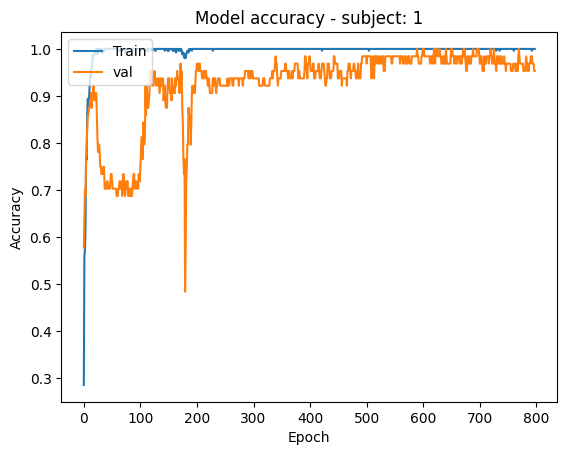

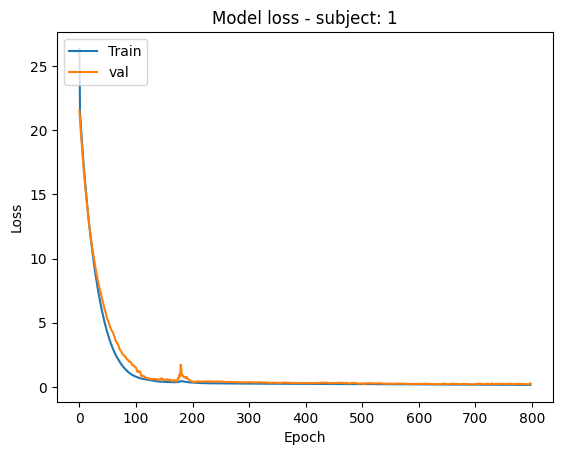


Training on subject  2
Creating RawArray with float64 data, n_channels=128, n_times=3131420
    Range : 0 ... 3131419 =      0.000 ...  6262.838 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
813 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
813 events found on stim channel STI 014
Event IDs: [2 4 6 8]
813 events found on stim channel STI 014
Event IDs: [2 4 6 8]
813 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=614290
    Range : 0 ... 614289 =      0.000 ...  1228.578 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 12:15:46.297483: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 12:16:06.474004: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 12:16:06.572010: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads



Epoch 578: early stopping
1/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/stepWARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7cdc4c489c60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 614ms/step
Subject: 2   seed 1   time: 5.7 m   valid_acc: 0.9325   valid_loss: 0.365
Epoch 421: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 532ms/step
Subject: 2   seed 2   time: 4.6 m   v

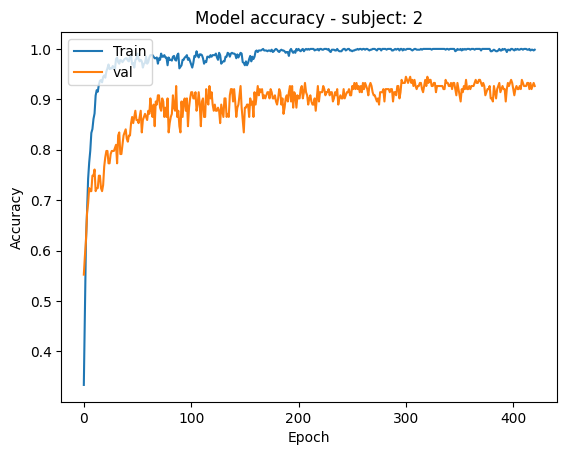

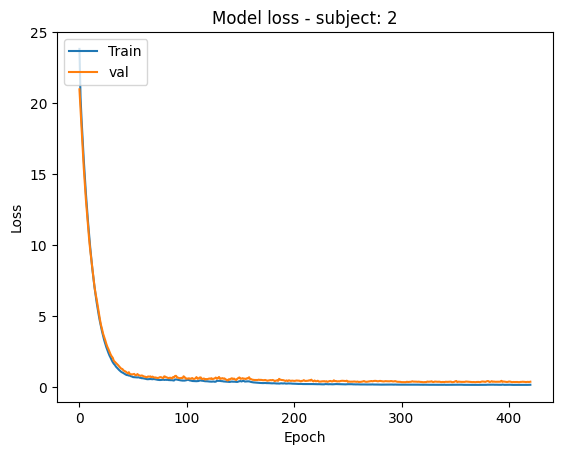


Training on subject  3
Creating RawArray with float64 data, n_channels=128, n_times=3347155
    Range : 0 ... 3347154 =      0.000 ...  6694.308 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=609030
    Range : 0 ... 609029 =      0.000 ...  1218.058 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 12:33:05.360652: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 12:33:05.548094: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads



Epoch 1154: early stopping
1/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

2025-12-19 12:42:30.997349: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 12:42:31.401912: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 810ms/step
Subject: 3   seed 1   time: 10.2 m   valid_acc: 0.9943   valid_loss: 0.128
Epoch 794: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 602ms/step
Subject: 3   seed 2   time: 7.4 m   valid_acc: 0.9886   valid_loss: 0.182
Epoch 561: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 462ms/step
Subject: 3   seed 3   time: 4.9 m   valid_acc: 0.9886   valid_loss: 0.216
Plot Learning Curves ....... 


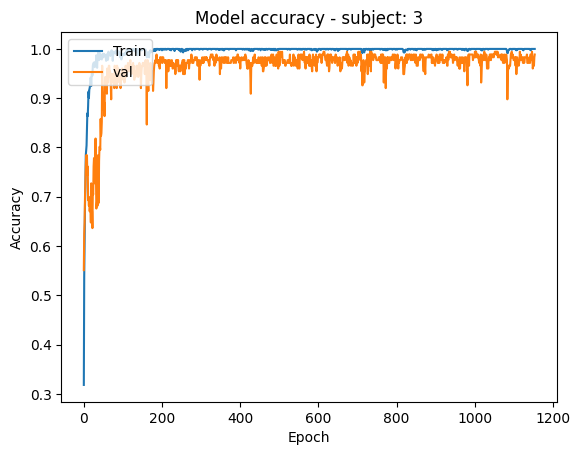

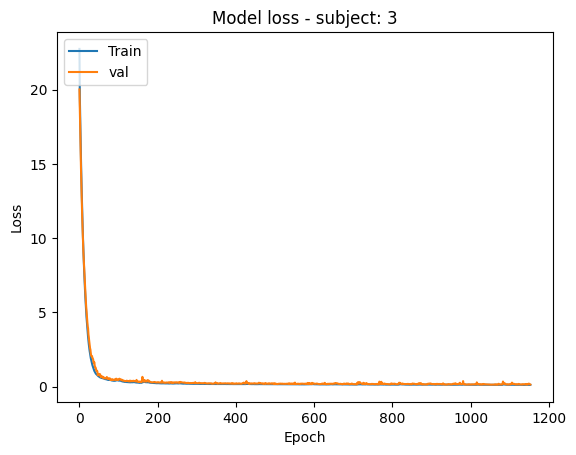


Training on subject  4
Creating RawArray with float64 data, n_channels=128, n_times=3451320
    Range : 0 ... 3451319 =      0.000 ...  6902.638 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
897 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
897 events found on stim channel STI 014
Event IDs: [2 4 6 8]
897 events found on stim channel STI 014
Event IDs: [2 4 6 8]
897 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=617090
    Range : 0 ... 617089 =      0.000 ...  1234.178 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 12:56:50.521972: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 12:56:51.414943: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 12:57:12.725313: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 12:57:12.953300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



Epoch 420: early stopping
1/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

2025-12-19 13:00:59.564786: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:00:59.936935: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 715ms/step
Subject: 4   seed 1   time: 5.0 m   valid_acc: 0.9721   valid_loss: 0.191
Epoch 553: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 508ms/step
Subject: 4   seed 2   time: 5.9 m   valid_acc: 0.9609   valid_loss: 0.157
Epoch 733: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 572ms/step
Subject: 4   seed 3   time: 7.5 m   valid_acc: 0.9832   valid_loss: 0.124
Plot Learning Curves ....... 


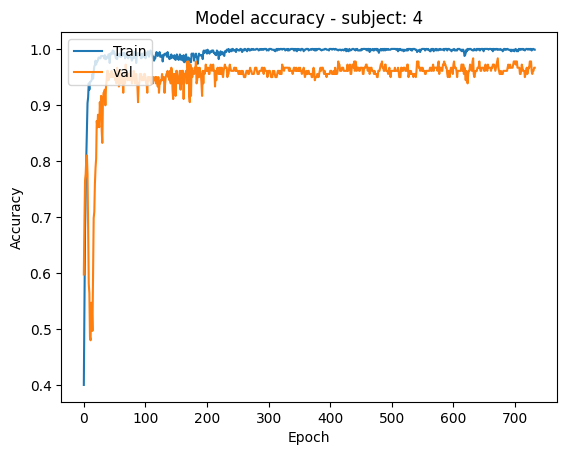

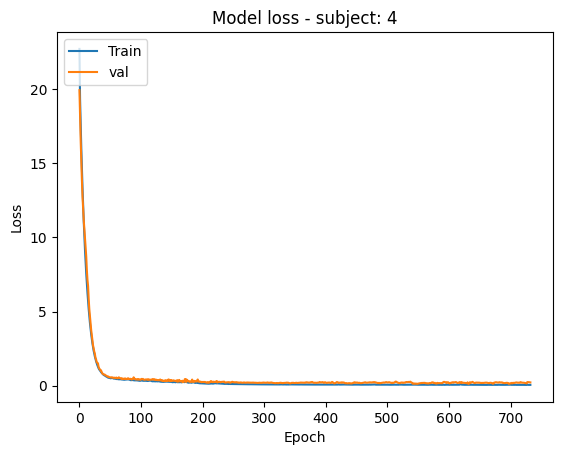


Training on subject  5
Creating RawArray with float64 data, n_channels=128, n_times=2736300
    Range : 0 ... 2736299 =      0.000 ...  5472.598 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
720 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
720 events found on stim channel STI 014
Event IDs: [2 4 6 8]
720 events found on stim channel STI 014
Event IDs: [2 4 6 8]
720 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=607250
    Range : 0 ... 607249 =      0.000 ...  1214.498 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

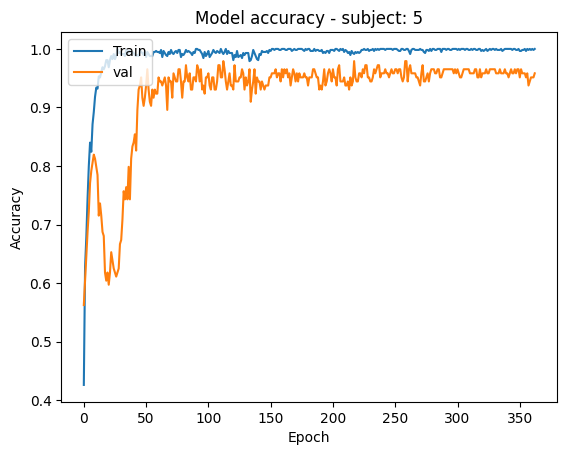

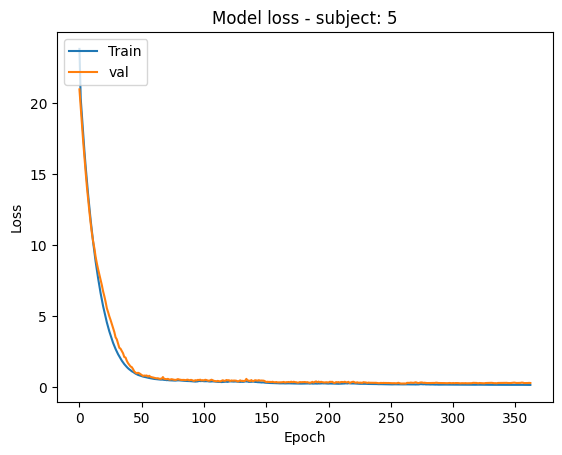


Training on subject  6
Creating RawArray with float64 data, n_channels=128, n_times=3387290
    Range : 0 ... 3387289 =      0.000 ...  6774.578 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=615705
    Range : 0 ... 615704 =      0.000 ...  1231.408 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 13:30:00.727456: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 13:30:01.079292: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:30:34.116009: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:30:34.263941: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



Epoch 551: early stopping
1/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step

2025-12-19 13:34:39.008535: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:34:39.226250: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 713ms/step
Subject: 6   seed 1   time: 5.5 m   valid_acc: 0.9543   valid_loss: 0.345
Epoch 832: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 513ms/step
Subject: 6   seed 2   time: 8.1 m   valid_acc: 0.9657   valid_loss: 0.242
Epoch 838: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 572ms/step
Subject: 6   seed 3   time: 8.3 m   valid_acc: 0.9600   valid_loss: 0.242
Plot Learning Curves ....... 


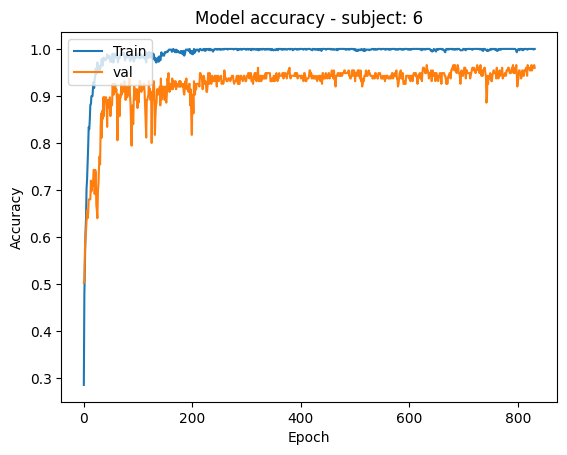

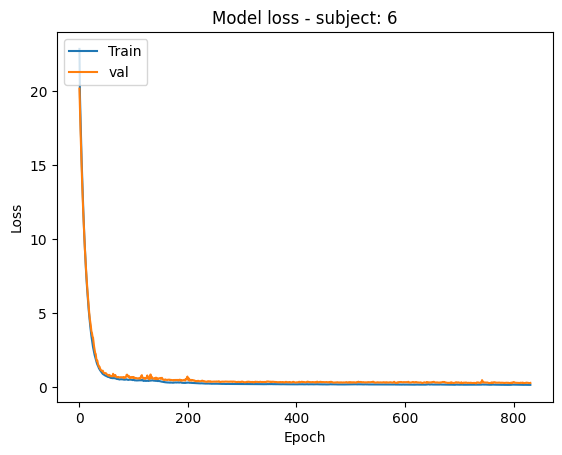


Training on subject  7
Creating RawArray with float64 data, n_channels=128, n_times=3354460
    Range : 0 ... 3354459 =      0.000 ...  6708.918 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=608850
    Range : 0 ... 608849 =      0.000 ...  1217.698 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 13:53:08.842458: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 13:53:09.759363: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:53:32.412866: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 13:53:32.445423: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



Epoch 549: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 626ms/step
Subject: 7   seed 1   time: 5.9 m   valid_acc: 0.9702   valid_loss: 0.246
Epoch 538: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step
Subject: 7   seed 2   time: 5.3 m   valid_acc: 0.9643   valid_loss: 0.247
Epoch 722: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step
Subject: 7   seed 3   time: 6.9 m   valid_acc: 0.9702   valid_loss: 0.237
Plot Learning Curves ....... 


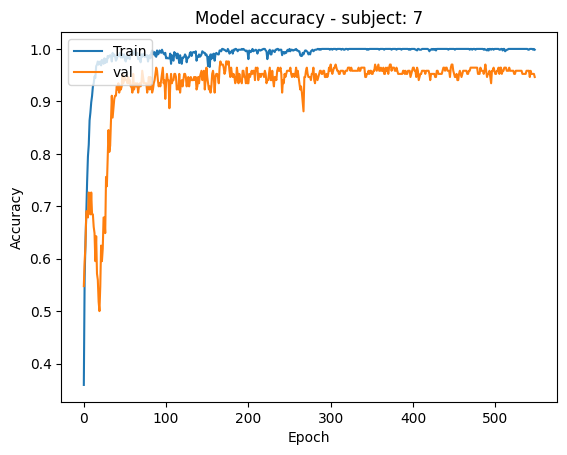

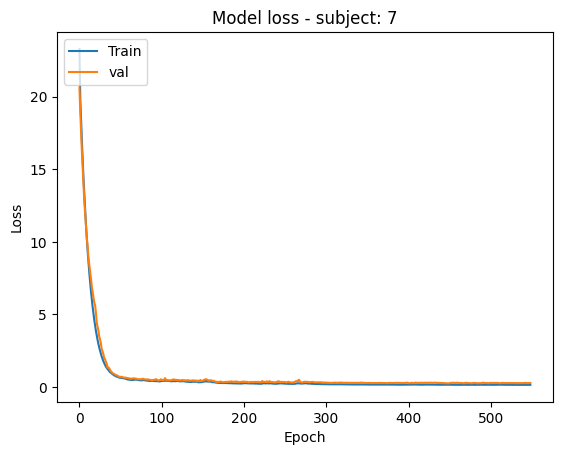


Training on subject  8
Creating RawArray with float64 data, n_channels=128, n_times=2511860
    Range : 0 ... 2511859 =      0.000 ...  5023.718 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=616070
    Range : 0 ... 616069 =      0.000 ...  1232.138 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

2025-12-19 14:12:13.882988: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 14:12:14.068756: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads



Epoch 551: early stopping
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 752ms/step
Subject: 8   seed 1   time: 5.2 m   valid_acc: 0.9313   valid_loss: 0.346
Epoch 619: early stopping
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 570ms/step
Subject: 8   seed 2   time: 5.7 m   valid_acc: 0.9466   valid_loss: 0.313
Epoch 314: early stopping
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 616ms/step
Subject: 8   seed 3   time: 3.2 m   valid_acc: 0.9237   valid_loss: 0.384
Plot Learning Curves ....... 


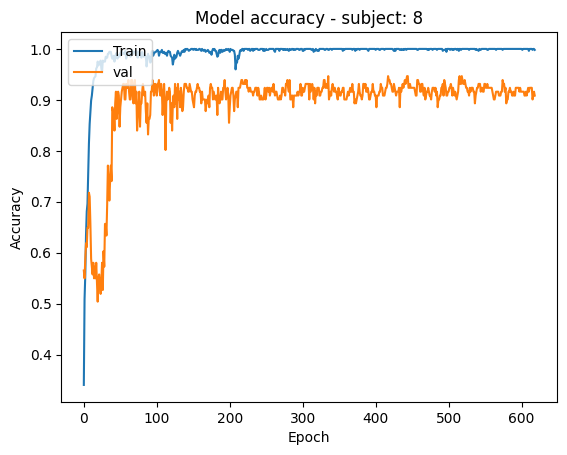

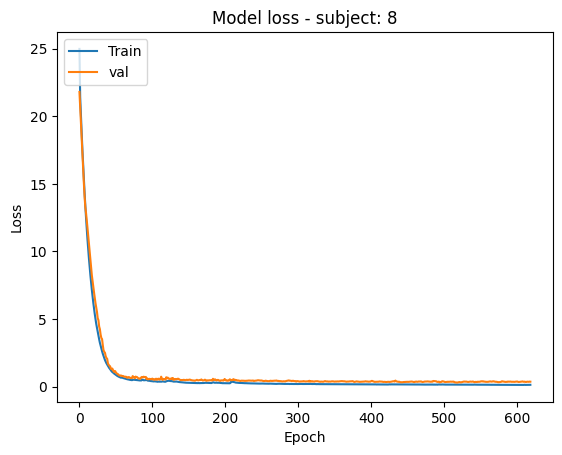


Training on subject  9
Creating RawArray with float64 data, n_channels=128, n_times=3383655
    Range : 0 ... 3383654 =      0.000 ...  6767.308 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=614600
    Range : 0 ... 614599 =      0.000 ...  1229.198 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found o

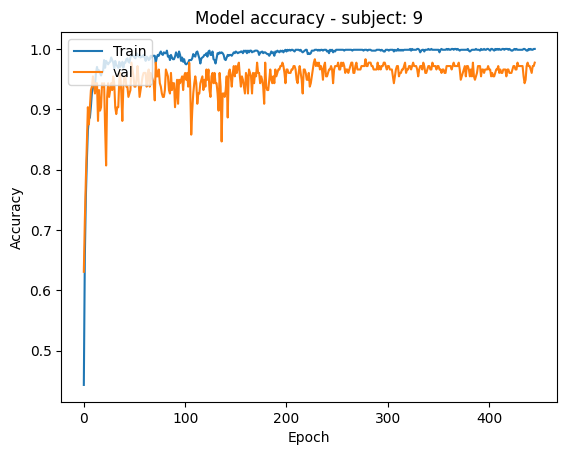

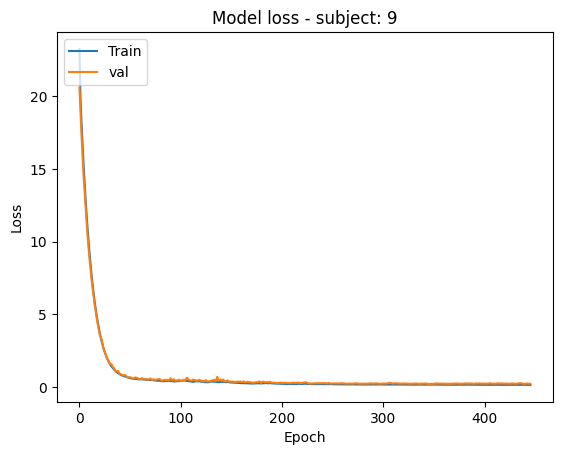


Training on subject  10
Creating RawArray with float64 data, n_channels=128, n_times=3386150
    Range : 0 ... 3386149 =      0.000 ...  6772.298 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=614555
    Range : 0 ... 614554 =      0.000 ...  1229.108 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found 

2025-12-19 14:42:44.327140: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 14:42:45.994862: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads

2025-12-19 14:43:07.442974: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 14:43:07.640661: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



Epoch 295: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 580ms/step
Subject: 10   seed 1   time: 3.7 m   valid_acc: 0.9512   valid_loss: 0.348
Epoch 453: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 453ms/step
Subject: 10   seed 2   time: 5.0 m   valid_acc: 0.9634   valid_loss: 0.318
Epoch 937: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step
Subject: 10   seed 3   time: 8.5 m   valid_acc: 0.9512   valid_loss: 0.207
Plot Learning Curves ....... 


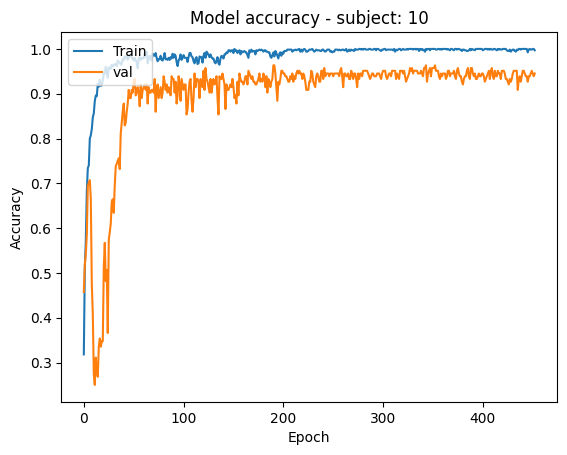

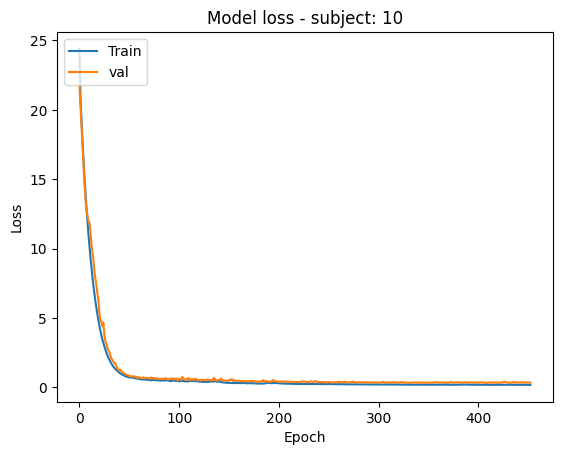


Training on subject  11
Creating RawArray with float64 data, n_channels=128, n_times=3386765
    Range : 0 ... 3386764 =      0.000 ...  6773.528 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=610820
    Range : 0 ... 610819 =      0.000 ...  1221.638 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found 

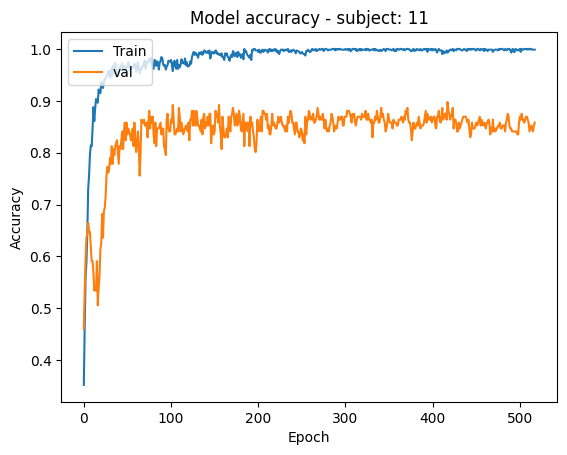

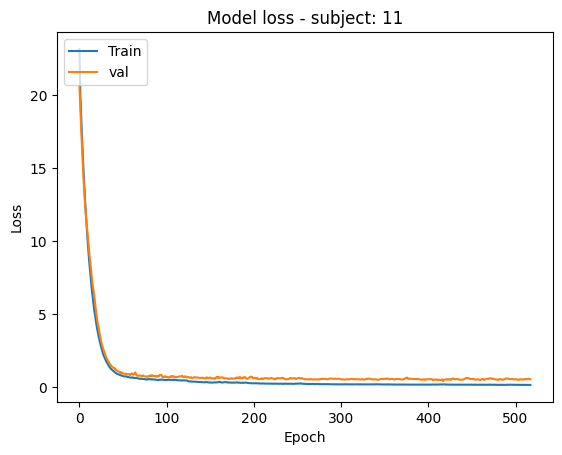


Training on subject  12
Creating RawArray with float64 data, n_channels=128, n_times=3385750
    Range : 0 ... 3385749 =      0.000 ...  6771.498 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=617735
    Range : 0 ... 617734 =      0.000 ...  1235.468 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found 

2025-12-19 15:15:55.280022: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 15:15:56.011325: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_94', 432 bytes spill stores, 432 bytes spill loads



Epoch 447: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 482ms/step
Subject: 12   seed 1   time: 5.3 m   valid_acc: 0.9943   valid_loss: 0.162
Epoch 612: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 561ms/step
Subject: 12   seed 2   time: 6.2 m   valid_acc: 0.9716   valid_loss: 0.176
Epoch 838: early stopping
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 456ms/step
Subject: 12   seed 3   time: 8.2 m   valid_acc: 0.9886   valid_loss: 0.152
Plot Learning Curves ....... 


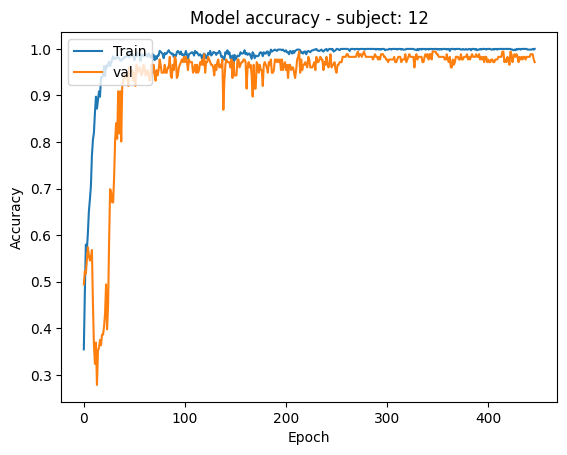

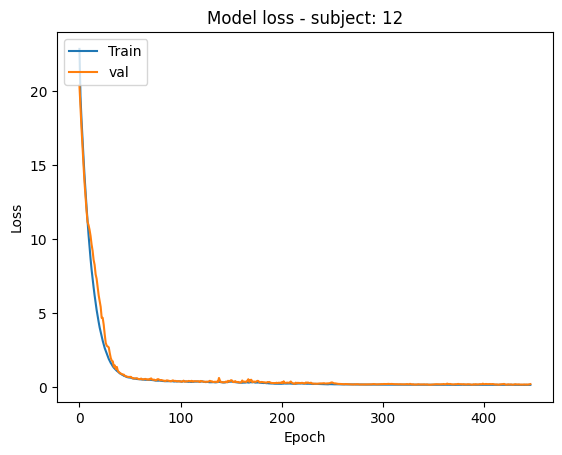


Training on subject  13
Creating RawArray with float64 data, n_channels=128, n_times=3032845
    Range : 0 ... 3032844 =      0.000 ...  6065.688 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
800 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
800 events found on stim channel STI 014
Event IDs: [2 4 6 8]
800 events found on stim channel STI 014
Event IDs: [2 4 6 8]
800 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=607735
    Range : 0 ... 607734 =      0.000 ...  1215.468 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found 

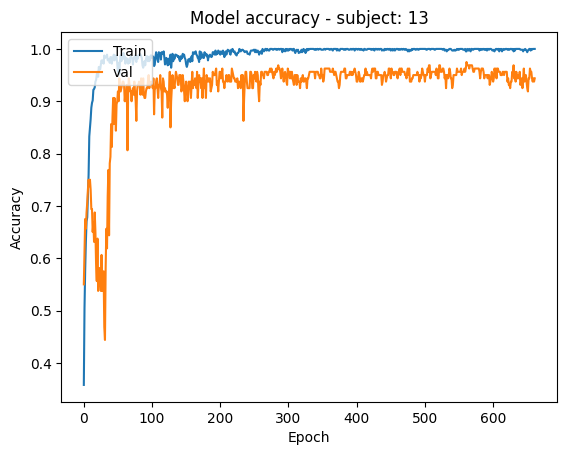

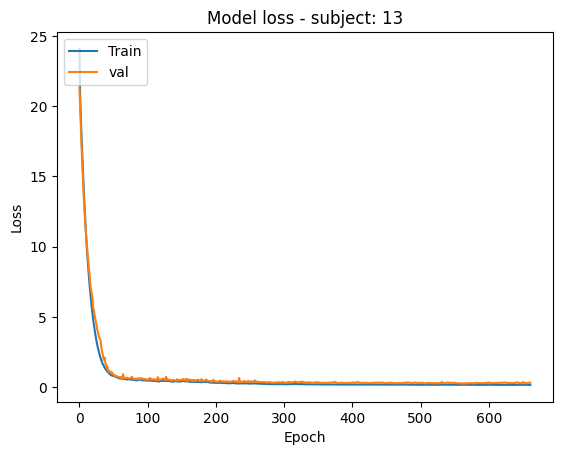


Training on subject  14
Creating RawArray with float64 data, n_channels=128, n_times=3345425
    Range : 0 ... 3345424 =      0.000 ...  6690.848 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
880 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=608505
    Range : 0 ... 608504 =      0.000 ...  1217.008 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
160 events found 

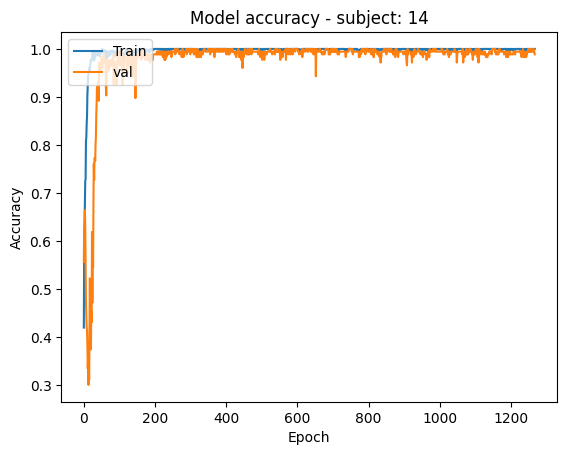

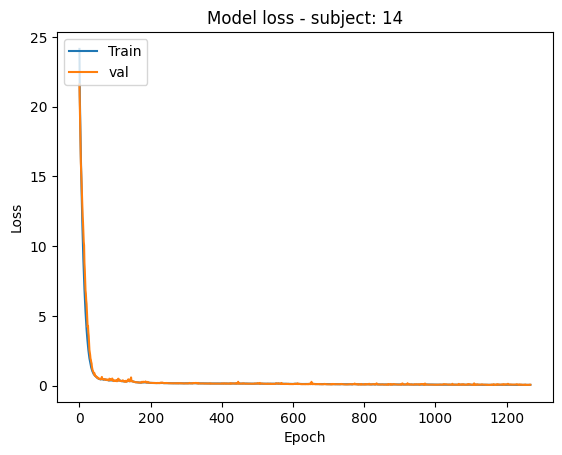


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9   sub_10   sub_11   sub_12   sub_13   sub_14     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  98.44   93.25   99.43   97.21   96.53   95.43   97.02   93.13   97.16   95.12   88.07   99.43   96.88   100.00     96.22   
Seed 2:  100.00   94.48   98.86   96.09   97.22   96.57   96.43   94.66   96.59   96.34   88.07   97.16   97.50   99.43     96.39   
Seed 3:  100.00   93.25   98.86   98.32   96.53   96.00   97.02   92.37   96.59   95.12   89.77   98.86   95.00   99.43     96.22   
---------------------------------
Average acc - all seeds: 96.28 %

Train Time  - all seeds: 261.9 min
---------------------------------

Training completed!
Creating RawArray with float64 data, n_channels=128, n_times=1225545
    Ra

2025-12-19 16:26:37.029750: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 12 bytes spill stores, 12 bytes spill loads

2025-12-19 16:26:37.550859: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 432 bytes spill stores, 432 bytes spill loads



5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 909ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Creating RawArray with float64 data, n_channels=128, n_times=2511860
    Range : 0 ... 2511859 =      0.000 ...  5023.718 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
654 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Creating RawArray with float64 data, n_channels=128, n_times=616070
    Range : 0 ... 616069 =      0.000 ...  1232.138 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
NOTE: pick_channels() is a legacy function. New code should use inst.

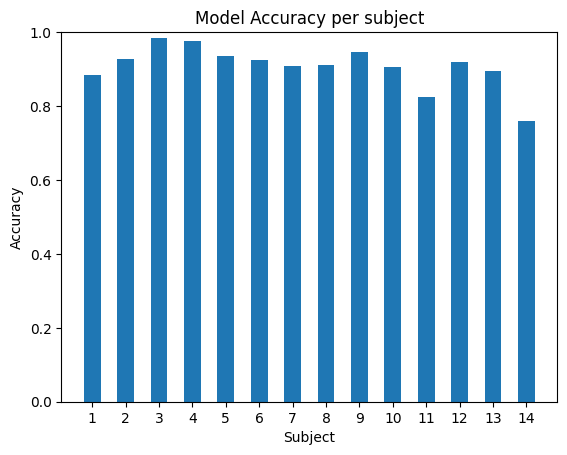

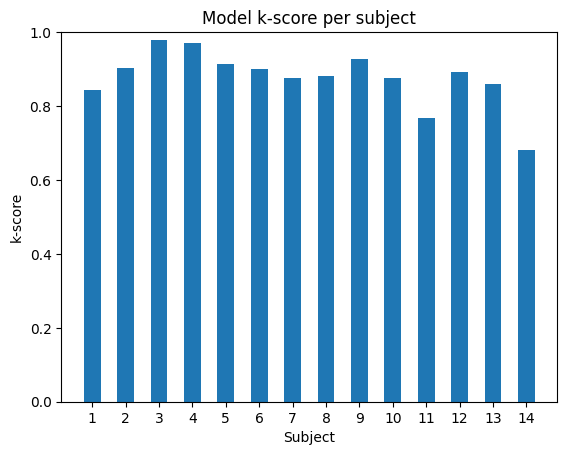

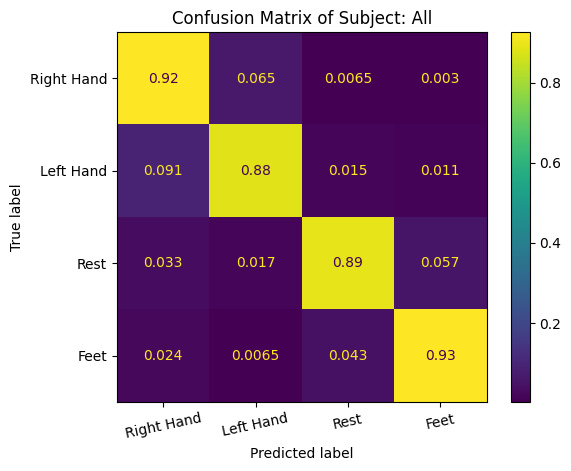

In [14]:
run("rdwt")